In [ ]:
!pip install koreanize-matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 51.6 MB/s eta 0:00:00


In [ ]:
!pip install folium mapclassify

# 공간데이터 dbf 파일 전처리


In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np

file_path = "/content/drive/MyDrive/비타민/서울시 공모전/TB_O_SSL_SC_2019.shp"
df_fac = gpd.read_file(file_path)


In [ ]:
def strip_all_columns(df):
    # 1. 컬럼명 자체의 공백 제거
    df.columns = df.columns.str.strip()

    # 2. 문자열(object) 타입인 컬럼만 골라서 데이터 내부 공백 제거
    str_cols = df.select_dtypes(['object']).columns
    for col in str_cols:
        df[col] = df[col].astype(str).str.strip()

    return df

df_fac = strip_all_columns(df_fac)

print("✅ 모든 행과 컬럼의 앞뒤 공백 제거가 완료되었습니다.")

✅ 모든 행과 컬럼의 앞뒤 공백 제거가 완료되었습니다.


In [ ]:
# 결측치 확인
print(df_fac.isnull().sum())

SEQ           0
LOC_CODE      0
CATEGORY1     0
CATEGORY2     0
FAC_NM        0
FAC_ADDR      0
TEL           0
LEGAL_DONG    0
SANJI_FLAG    0
BON_NO        0
BU_NO         0
GU            0
ETC_ADDR      0
SCALE         0
CAPACITY      0
FOUNDER       0
OPERATOR      0
CHIEF         0
OPEN_DATE     0
UPD_DATE      0
REG_DATE      0
MAX_CNT       0
REGIS_CNT     0
WAIT_CNT      0
VACANCY_CN    0
KIND          0
TM_X          0
TM_Y          0
geometry      0
dtype: int64


In [ ]:
df_fac = df_fac.dropna(axis=1, how='all')
print(df_fac.isnull().sum())

SEQ           0
LOC_CODE      0
CATEGORY1     0
CATEGORY2     0
FAC_NM        0
FAC_ADDR      0
TEL           0
LEGAL_DONG    0
SANJI_FLAG    0
BON_NO        0
BU_NO         0
GU            0
ETC_ADDR      0
SCALE         0
CAPACITY      0
FOUNDER       0
OPERATOR      0
CHIEF         0
OPEN_DATE     0
UPD_DATE      0
REG_DATE      0
MAX_CNT       0
REGIS_CNT     0
WAIT_CNT      0
VACANCY_CN    0
KIND          0
TM_X          0
TM_Y          0
geometry      0
dtype: int64


In [ ]:
# 1. LOC_CODE별로 그룹화하여 개수 산출
loc_counts = df_fac.groupby('LOC_CODE').size().reset_index(name='FAC_CNT')

# 2. 시설이 많은 순서대로 정렬
loc_counts = loc_counts.sort_values(by='FAC_CNT', ascending=False)

print("--- [LOC_CODE별 노인복지시설 개수 집계] ---")
display(loc_counts)
print(f"\n총 시설 개수: {loc_counts['FAC_CNT'].sum()}개")

--- [LOC_CODE별 노인복지시설 개수 집계] ---


,LOC_CODE,FAC_CNT
9,도봉구,71
24,중랑구,68
8,노원구,49
3,강서구,48
4,관악구,48
18,양천구,48
2,강북구,46
10,동대문구,45
17,송파구,43
1,강동구,42



총 시설 개수: 874개


### 필요없는 컬럼 삭제

In [ ]:
df_fac_selected = df_fac[['FAC_NM', 'MAX_CNT', 'TM_X', 'TM_Y']].copy()

df_fac_selected.head()

,FAC_NM,MAX_CNT,TM_X,TM_Y
0,청운노인요양원,45.0,195998.893305,557267.518940
1,인자인케어센터,42.0,197055.981139,557030.813522
2,평창동시니어센터,68.0,196969.235834,556780.743523
3,아름다운뜰안에 요양원,38.0,197200.744530,556883.857236
4,서울여자간호대학교 휴먼캐슬,38.0,197988.453627,557157.815102


# 독거노인현황 데이터 전처리

In [ ]:
import pandas as pd
# 1. 데이터 불러오기 (컬럼명이 다중 레벨일 수 있으니 확인 필요)
df_solo = pd.read_csv("/content/drive/MyDrive/비타민/서울시 공모전/독거노인현황_연령별_동별.csv")
df_solo = strip_all_columns(df_solo)
print("✅ 모든 행과 컬럼의 앞뒤 공백 제거가 완료되었습니다.")
df_solo.head()

✅ 모든 행과 컬럼의 앞뒤 공백 제거가 완료되었습니다.


,구,동,계,65~79세,80세 이상,기초계,기초65~79세,기초80세 이상,저소득계,저소득65~79세,저소득80세 이상,일반계,일반65~79세,일반80세 이상
0,소계,소계,494926,356556,138370,142005,96231,45774,15543,8916,6627,337378,251409,85969
1,종로구,소계,9076,6296,2780,2363,1711,652,371,214,157,6342,4371,1971
2,종로구,사직동,510,317,193,69,41,28,21,21,-,420,255,165
3,종로구,삼청동,177,115,62,20,12,8,6,1,5,151,102,49
4,종로구,부암동,438,298,140,56,32,24,14,5,9,368,261,107


In [ ]:
# 2. 불필요한 행 제거 (합계, 구별 소계 제거)
# '동' 컬럼이 '소계'인 행을 삭제합니다.
df_solo = df_solo[df_solo['동'] != '소계']
df_solo = df_solo[df_solo['구'] != '소계']
df_solo.head()

,구,동,계,65~79세,80세 이상,기초계,기초65~79세,기초80세 이상,저소득계,저소득65~79세,저소득80세 이상,일반계,일반65~79세,일반80세 이상
2,종로구,사직동,510,317,193,69,41,28,21,21,-,420,255,165
3,종로구,삼청동,177,115,62,20,12,8,6,1,5,151,102,49
4,종로구,부암동,438,298,140,56,32,24,14,5,9,368,261,107
5,종로구,평창동,799,476,323,61,37,24,31,17,14,707,422,285
6,종로구,무악동,340,214,126,103,74,29,9,2,7,228,138,90


In [ ]:
# 3. 결측치 및 기호 처리
target_cols = [col for col in df_solo.columns if col not in ['구', '동']]
for col in target_cols:
    # 모든 값을 문자열로 강제 변환 후 특수기호 제거
    df_solo[col] = df_solo[col].astype(str).str.replace('-', '0').str.replace(',', '')
    # 마지막에 숫자로 변환 (변환 불가능한 값은 NaN으로 처리 후 0으로 채움)
    df_solo[col] = pd.to_numeric(df_solo[col], errors='coerce').fillna(0).astype(int)
df_solo=df_solo.reset_index(drop=True)
df_solo.head()

,구,동,계,65~79세,80세 이상,기초계,기초65~79세,기초80세 이상,저소득계,저소득65~79세,저소득80세 이상,일반계,일반65~79세,일반80세 이상
0,종로구,사직동,510,317,193,69,41,28,21,21,0,420,255,165
1,종로구,삼청동,177,115,62,20,12,8,6,1,5,151,102,49
2,종로구,부암동,438,298,140,56,32,24,14,5,9,368,261,107
3,종로구,평창동,799,476,323,61,37,24,31,17,14,707,422,285
4,종로구,무악동,340,214,126,103,74,29,9,2,7,228,138,90


In [ ]:
print("--- [독거노인 인구 상위 10개 행정동] ---")
display(df_solo.sort_values(by='계', ascending=False)[['구', '동', '계']].head(10))

--- [독거노인 인구 상위 10개 행정동] ---


,구,동,계
243,강서구,등촌3동,5656
374,강남구,수서동,4249
251,강서구,가양2동,3838
258,강서구,화곡1동,3362
257,강서구,방화3동,3154
281,금천구,시흥1동,3095
129,성북구,석관동,2908
174,노원구,중계2.3동,2836
256,강서구,방화2동,2718
128,성북구,종암동,2673


In [ ]:
# 기초수급(3.0) > 저소득(2.0) > 일반(1.0) 순으로 차등을 두고,
# 80세 이상에게는 연령 가중치(1.3배)를 추가 부여합니다.

weights = {
    '기초80세 이상': 3.0 * 1.3,     # 3.9 (초고위험)
    '기초65~79세': 3.0 * 1.0,      # 3.0 (중고위험)
    '저소득80세 이상': 2.0 * 1.3,   # 2.6 (고위험)
    '저소득65~79세': 2.0 * 1.0,    # 2.0 (중위험)
    '일반80세 이상': 1.0 * 1.3,     # 1.3 (저위험)
    '일반65~79세': 1.0 * 1.0       # 1.0 (일반 관리)
}

# 2. 위험 점수(weighted_demand) 계산
df_solo['weighted_demand'] = (
    df_solo['기초80세 이상'] * weights['기초80세 이상'] +
    df_solo['기초65~79세'] * weights['기초65~79세'] +
    df_solo['저소득80세 이상'] * weights['저소득80세 이상'] +
    df_solo['저소득65~79세'] * weights['저소득65~79세'] +
    df_solo['일반80세 이상'] * weights['일반80세 이상'] +
    df_solo['일반65~79세'] * weights['일반65~79세']
)

In [ ]:
df_solo = df_solo.rename(columns={
    '구': '자치구',
    '동': '행정동'
})

df_solo_selected = df_solo[['자치구', '행정동', 'weighted_demand']].copy()

In [ ]:
df_solo_selected.head()

,자치구,행정동,weighted_demand
0,종로구,사직동,743.7
1,종로구,삼청동,247.9
2,종로구,부암동,623.1
3,종로구,평창동,1067.5
4,종로구,무악동,612.3


# 서울시 행정동 경계 데이터와 통일

In [ ]:
admin_dong_map = gpd.read_file("/content/drive/MyDrive/비타민/서울시 공모전/bnd_dong_11_2025_2Q.shp")

In [ ]:
# 1. 각 데이터셋의 동 이름 추출 (공백 제거 후 고유값만)
solo_dongs = set(df_solo_selected['행정동'].str.strip().unique())
map_dongs = set(admin_dong_map['ADM_NM'].str.strip().unique())

# 2. 통계 산출
common_dongs = solo_dongs.intersection(map_dongs)       # 교집합 (겹치는 동)
only_solo = solo_dongs - map_dongs                      # df_solo에만 있는 동
only_map = map_dongs - solo_dongs                       # admin_dong_map에만 있는 동

# 3. 결과 출력
print(f"--- [데이터 대조 결과 보고서] ---")
print(f"1. df_solo (독거노인) 동 개수: {len(solo_dongs)}개")
print(f"2. admin_dong_map (지도) 동 개수: {len(map_dongs)}개")
print(f"3. 완벽히 일치하는 동 개수: {len(common_dongs)}개")
print(f"4. 이름이 달라 매칭 실패한 동 개수: {len(only_solo) + len(only_map)}개")

print("\n--- [체크 필요: df_solo에만 있는 동 (일부)] ---")
print(sorted(list(only_solo))[:20])  # 상위 20개만 출력

print("\n--- [체크 필요: admin_dong_map에만 있는 동 (일부)] ---")
print(sorted(list(only_map))[:20])   # 상위 20개만 출력

--- [데이터 대조 결과 보고서] ---
1. df_solo (독거노인) 동 개수: 425개
2. admin_dong_map (지도) 동 개수: 425개
3. 완벽히 일치하는 동 개수: 414개
4. 이름이 달라 매칭 실패한 동 개수: 22개

--- [체크 필요: df_solo에만 있는 동 (일부)] ---
['금호2.3가동', '면목3.8동', '상계3.4동', '상계6.7동', '정능1동', '정능2동', '정능3동', '정능4동', '종로1.2.3.4가동', '종로5.6가동', '중계2.3동']

--- [체크 필요: admin_dong_map에만 있는 동 (일부)] ---
['금호2·3가동', '면목3·8동', '상계3·4동', '상계6·7동', '정릉1동', '정릉2동', '정릉3동', '정릉4동', '종로1·2·3·4가동', '종로5·6가동', '중계2·3동']


In [ ]:
def finalize_dong_names(df, col_name):
    # 1. 양쪽의 공백 제거
    df[col_name] = df[col_name].str.strip()

    # 2. 특수문자 통일 (마침표를 가운뎃점으로)
    df[col_name] = df[col_name].str.replace('.', '·', regex=False)

    # 3. 특정 오타 교정 ('정능' -> '정릉')
    df[col_name] = df[col_name].str.replace('정능', '정릉', regex=False)

    return df

# 양쪽 데이터에 적용 (admin_dong_map의 컬럼명이 ADM_DR_NM인 경우)
df_solo = finalize_dong_names(df_solo_selected, '행정동')
admin_dong_map = finalize_dong_names(admin_dong_map, 'ADM_NM')

print("✅ 동 명칭 정규화 완료 (특수문자 및 오타 교정)")

✅ 동 명칭 정규화 완료 (특수문자 및 오타 교정)


In [ ]:
# 1. 각 데이터셋의 동 이름 추출 (공백 제거 후 고유값만)
solo_dongs = set(df_solo_selected['행정동'].str.strip().unique())
map_dongs = set(admin_dong_map['ADM_NM'].str.strip().unique())

# 2. 통계 산출
common_dongs = solo_dongs.intersection(map_dongs)       # 교집합 (겹치는 동)
only_solo = solo_dongs - map_dongs                      # df_solo에만 있는 동
only_map = map_dongs - solo_dongs                       # admin_dong_map에만 있는 동

# 3. 결과 출력
print(f"--- [데이터 대조 결과 보고서] ---")
print(f"1. df_solo (독거노인) 동 개수: {len(solo_dongs)}개")
print(f"2. admin_dong_map (지도) 동 개수: {len(map_dongs)}개")
print(f"3. 완벽히 일치하는 동 개수: {len(common_dongs)}개")
print(f"4. 이름이 달라 매칭 실패한 동 개수: {len(only_solo) + len(only_map)}개")

print("\n--- [체크 필요: df_solo에만 있는 동 (일부)] ---")
print(sorted(list(only_solo))[:20])  # 상위 20개만 출력

print("\n--- [체크 필요: admin_dong_map에만 있는 동 (일부)] ---")
print(sorted(list(only_map))[:20])   # 상위 20개만 출력

--- [데이터 대조 결과 보고서] ---
1. df_solo (독거노인) 동 개수: 425개
2. admin_dong_map (지도) 동 개수: 425개
3. 완벽히 일치하는 동 개수: 425개
4. 이름이 달라 매칭 실패한 동 개수: 0개

--- [체크 필요: df_solo에만 있는 동 (일부)] ---
[]

--- [체크 필요: admin_dong_map에만 있는 동 (일부)] ---
[]


In [ ]:
admin_dong_map = admin_dong_map.drop(columns=['BASE_DATE'])

admin_dong_map = admin_dong_map.rename(columns={
    'ADM_NM': '행정동',
    'ADM_CD': '행정동코드'
})

In [ ]:
admin_dong_map = admin_dong_map.to_crs(epsg=5179)

admin_dong_map['area_km2'] = admin_dong_map.geometry.area / 1_000_000

admin_dong_map = admin_dong_map[['행정동코드', '행정동', 'area_km2', 'geometry']]

admin_dong_map.head()

,행정동코드,행정동,area_km2,geometry
0,11010530,사직동,1.157671,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,11010540,삼청동,1.477188,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,11010550,부암동,2.273287,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,11010560,평창동,8.940413,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,11010570,무악동,0.369245,"POLYGON ((952298.144 1953539.606, 952324.838 1..."


In [ ]:
district_mapping = df_solo_selected[['자치구', '행정동']].drop_duplicates()
print(district_mapping[district_mapping['행정동'] == '신사동'])

     자치구  행정동
329  관악구  신사동
358  강남구  신사동


In [ ]:
admin_dong_map_updated = pd.merge(admin_dong_map, district_mapping, on='행정동', how='left')
sinsa_check = admin_dong_map_updated[admin_dong_map_updated['행정동'] == '신사동']
print(sinsa_check)

        행정동코드  행정동  area_km2  \
329  11210680  신사동  0.640630   
330  11210680  신사동  0.640630   
359  11230510  신사동  2.057678   
360  11230510  신사동  2.057678   

                                              geometry  자치구  
329  POLYGON ((949226.005 1942926.412, 949226.964 1...  관악구  
330  POLYGON ((949226.005 1942926.412, 949226.964 1...  강남구  
359  POLYGON ((957731.011 1948575.766, 957965.468 1...  관악구  
360  POLYGON ((957731.011 1948575.766, 957965.468 1...  강남구  


In [ ]:
# 1. 문제가 되는 인덱스(330, 359) 제거
admin_dong_map_final = admin_dong_map_updated.drop([330, 359])

# 2. 인덱스 초기화 (기존 인덱스는 삭제)
admin_dong_map_final = admin_dong_map_final.reset_index(drop=True)

# 확인
print(admin_dong_map_final[admin_dong_map_final['행정동'] == '신사동'])

        행정동코드  행정동  area_km2  \
329  11210680  신사동  0.640630   
358  11230510  신사동  2.057678   

                                              geometry  자치구  
329  POLYGON ((949226.005 1942926.412, 949226.964 1...  관악구  
358  POLYGON ((957731.011 1948575.766, 957965.468 1...  강남구  


In [ ]:
df_no_geom = admin_dong_map_final.drop(columns='geometry', errors='ignore')
df_no_geom.to_csv('output.csv', index=False, encoding='utf-8-sig')

In [ ]:
# '자치구'와 '행정동'을 기준으로 내부 조인(inner merge) 수행
# 만약 한쪽에만 있는 데이터도 유지하고 싶다면 how='left'를 사용하세요.
final_df = pd.merge(df_solo_selected, admin_dong_map_final, on=['자치구', '행정동'], how='inner')

# 결과 확인
print(final_df.head())

# 신사동 데이터가 의도한 대로 1:1 매핑되었는지 최종 확인
print("\n--- 신사동 병합 결과 확인 ---")
print(final_df[final_df['행정동'] == '신사동'])

   자치구  행정동  weighted_demand     행정동코드  area_km2  \
0  종로구  사직동            743.7  11010530  1.157671   
1  종로구  삼청동            247.9  11010540  1.477188   
2  종로구  부암동            623.1  11010550  2.273287   
3  종로구  평창동           1067.5  11010560  8.940413   
4  종로구  무악동            612.3  11010570  0.369245   

                                            geometry  
0  POLYGON ((953553.932 1953335.741, 953555.211 1...  
1  POLYGON ((953844.082 1955492.177, 953858.644 1...  
2  POLYGON ((952490.38 1956548.821, 952497.594 19...  
3  POLYGON ((953683.828 1959209.871, 953665.283 1...  
4  POLYGON ((952298.144 1953539.606, 952324.838 1...  

--- 신사동 병합 결과 확인 ---
     자치구  행정동  weighted_demand     행정동코드  area_km2  \
329  관악구  신사동           2142.6  11210680  0.640630   
358  강남구  신사동            828.6  11230510  2.057678   

                                              geometry  
329  POLYGON ((949226.005 1942926.412, 949226.964 1...  
358  POLYGON ((957731.011 1948575.766, 957965.468 1...  


In [ ]:
# '행정동' 컬럼에서 '상일1동'을 '상일동'으로 변경
final_df['행정동'] = final_df['행정동'].replace('상일1동', '상일동')

# 수정 결과 확인
print(final_df[final_df['행정동'].str.contains('상일')][['행정동', '행정동코드']])

      행정동     행정동코드
424   상일동  11250760
425  상일2동  11250770


In [ ]:
# '상일2동' 또는 '강일동'인 행만 추출
target_rows = final_df[final_df['행정동'].isin(['상일2동', '강일동'])]

# 결과 출력
print("--- 필터링 결과 (상일2동, 강일동) ---")
display(target_rows)

--- 필터링 결과 (상일2동, 강일동) ---


,자치구,행정동,weighted_demand,행정동코드,area_km2,geometry
423,강동구,강일동,3408.5,11250750,2.270384,"POLYGON ((971452.641 1953347.663, 971446.624 1..."
425,강동구,상일2동,1169.6,11250770,1.115525,"POLYGON ((971880.053 1951049.53, 971880.001 19..."


In [ ]:
from shapely.ops import unary_union

# 1. 상일2동과 강일동 데이터 추출
sangil2 = final_df[final_df['행정동'] == '상일2동']
gangil = final_df[final_df['행정동'] == '강일동']

if not sangil2.empty and not gangil.empty:
    # 2. 수치 데이터 합산 (weighted_demand, area_km2)
    new_weighted_demand = sangil2['weighted_demand'].values[0] + gangil['weighted_demand'].values[0]
    new_area_km2 = sangil2['area_km2'].values[0] + gangil['area_km2'].values[0]

    # 3. Geometry 합치기 (두 폴리곤의 합집합)
    new_geometry = unary_union([sangil2['geometry'].values[0], gangil['geometry'].values[0]])

    # 4. 강일동 행 업데이트
    final_df.loc[final_df['행정동'] == '강일동', 'weighted_demand'] = new_weighted_demand
    final_df.loc[final_df['행정동'] == '강일동', 'area_km2'] = new_area_km2
    final_df.loc[final_df['행정동'] == '강일동', 'geometry'] = new_geometry

    # 5. 통합된 상일2동 행 삭제
    final_df = final_df[final_df['행정동'] != '상일2동']

    print("상일2동 데이터를 강일동으로 성공적으로 통합하였습니다.")
else:
    print("상일2동 또는 강일동 데이터를 찾을 수 없습니다. 명칭을 확인해 주세요.")

# 결과 확인
display(final_df[final_df['행정동'] == '강일동'])

상일2동 데이터를 강일동으로 성공적으로 통합하였습니다.


,자치구,행정동,weighted_demand,행정동코드,area_km2,geometry
423,강동구,강일동,4578.1,11250750,3.385909,"POLYGON ((971890.728 1951042.68, 971887.303 19..."


In [ ]:
print(len(final_df))

425


In [ ]:
from sklearn.preprocessing import StandardScaler
z_scaler = StandardScaler()

In [ ]:
final_df['density'] = np.log1p(final_df['weighted_demand'] / final_df['area_km2'])

final_df['density_norm'] = (
    final_df['density'] - final_df['density'].min()
) / (
    final_df['density'].max() - final_df['density'].min()
)

In [ ]:
beta = 0.3

final_df['adjusted_demand'] = (
    final_df['weighted_demand'] * (final_df['density_norm'] ** beta)
)

final_df['adjusted_demand'] = np.log1p(final_df['adjusted_demand'])

final_df['demand_score'] = (
    final_df['adjusted_demand'] - final_df['adjusted_demand'].min()
) / (
    final_df['adjusted_demand'].max() - final_df['adjusted_demand'].min()
)

In [ ]:
final_df[['행정동', 'density_norm']].sort_values(by='density_norm', ascending=False).head(10)

,행정동,density_norm
243,등촌3동,1.000000
252,가양3동,0.997789
251,가양2동,0.983657
174,중계2·3동,0.952052
263,구로4동,0.928439
190,응암3동,0.926232
414,천호3동,0.924088
420,암사1동,0.913837
278,독산2동,0.912951
107,면목본동,0.912602


In [ ]:
final_df[['행정동', 'demand_score']].sort_values(by='demand_score', ascending=False).head(10)

,행정동,demand_score
243,등촌3동,1.000000
374,수서동,0.964905
251,가양2동,0.958171
174,중계2·3동,0.941198
257,방화3동,0.920165
258,화곡1동,0.914464
252,가양3동,0.911494
281,시흥1동,0.910200
191,역촌동,0.907268
158,월계2동,0.902862


In [ ]:
print(final_df['demand_score'].describe())

count    425.000000
mean       0.784934
std        0.080945
min        0.000000
25%        0.741462
50%        0.791464
75%        0.838007
max        1.000000
Name: demand_score, dtype: float64


In [ ]:
gdf_fac = gpd.GeoDataFrame(
    df_fac_selected,
    geometry=gpd.points_from_xy(df_fac_selected['TM_X'], df_fac_selected['TM_Y']),
    crs="EPSG:5186"
)


final_df = gpd.GeoDataFrame(final_df, geometry='geometry', crs="EPSG:5179")

gdf_fac = gdf_fac.to_crs(epsg=5179)

joined = gpd.sjoin(
    gdf_fac,
    final_df[['행정동코드', 'geometry']],
    how='left',
    predicate='within'
)

fac_cnt = (
    joined.groupby('행정동코드')
    .size()
    .reset_index(name='FAC_CNT')
)

capacity_sum = (
    joined.groupby('행정동코드')['MAX_CNT']
    .sum()
    .reset_index(name='total_capacity')
)

final_df = final_df.merge(fac_cnt, on='행정동코드', how='left')
final_df = final_df.merge(capacity_sum, on='행정동코드', how='left')


In [ ]:
final_df[['FAC_CNT', 'total_capacity']].isnull().sum()

,0
FAC_CNT,140
total_capacity,140


In [ ]:
final_df['FAC_CNT'] = final_df['FAC_CNT'].fillna(0)
final_df['total_capacity'] = final_df['total_capacity'].fillna(0)

In [ ]:
final_df.head(10)

,자치구,행정동,weighted_demand,행정동코드,area_km2,geometry,density,density_norm,adjusted_demand,demand_score,FAC_CNT,total_capacity
0,종로구,사직동,743.7,11010530,1.157671,"POLYGON ((953553.932 1953335.741, 953555.211 1...",6.466783,0.655146,6.486294,0.694444,0.0,0.0
1,종로구,삼청동,247.9,11010540,1.477188,"POLYGON ((953844.082 1955492.177, 953858.644 1...",5.128827,0.491273,5.304779,0.567947,0.0,0.0
2,종로구,부암동,623.1,11010550,2.273287,"POLYGON ((952490.38 1956548.821, 952497.594 19...",5.617122,0.551079,6.257861,0.669987,1.0,77.0
3,종로구,평창동,1067.5,11010560,8.940413,"POLYGON ((953683.828 1959209.871, 953665.283 1...",4.790833,0.449876,6.734629,0.721031,8.0,290.0
4,종로구,무악동,612.3,11010570,0.369245,"POLYGON ((952298.144 1953539.606, 952324.838 1...",7.414119,0.771175,6.341034,0.678892,0.0,0.0
5,종로구,교남동,787.4,11010580,0.346667,"POLYGON ((952572.048 1953258.829, 952573.175 1...",7.728567,0.809688,6.606757,0.707341,0.0,0.0
6,종로구,가회동,357.6,11010600,0.539600,"POLYGON ((954894.795 1954614.58, 954888.29 195...",6.497850,0.658951,5.757447,0.616411,0.0,0.0
7,종로구,종로1·2·3·4가동,2222.4,11010610,2.414221,"POLYGON ((954918.389 1954371.538, 954926.411 1...",6.826052,0.699149,7.599476,0.813625,0.0,0.0
8,종로구,종로5·6가동,846.0,11010630,0.602713,"POLYGON ((956606.811 1953149.973, 956606.726 1...",7.247546,0.750773,6.655811,0.712593,0.0,0.0
9,종로구,이화동,743.2,11010640,0.781810,"POLYGON ((956365.891 1954112.187, 956371.71 19...",6.858160,0.703081,6.506775,0.696637,2.0,19.0


In [ ]:
import pandas as pd
import geopandas as gpd
from libpysal.weights import Queen
import numpy as np

# 1. Queen 인접성 가중치 생성
# final_df의 geometry를 기준으로 인접 행정동 네트워크를 형성합니다.
w = Queen.from_dataframe(final_df)

# 2. 인접 행정동의 total_capacity 합산 함수
def get_neighbor_capacity_queen(idx, weight_matrix, df, col_name):
    # 해당 행정동의 인접 이웃 인덱스 가져오기
    neighbors = weight_matrix.neighbors[idx]

    if not neighbors: # 만약 섬처럼 떨어진 지역이 있다면 0 반환
        return 0

    # 인접 동네들의 total_capacity 합산 후 30% 비중 적용
    neighbor_sum = df.loc[neighbors, col_name].sum() * 0.3
    return neighbor_sum

# 3. 인접 인프라 반영 지표 산출
# 각 행 행정동에 대해 인접 동네의 용량 계산
final_df['neighbor_capacity_adj'] = [
    get_neighbor_capacity_queen(i, w, final_df, 'total_capacity')
    for i in range(len(final_df))
]



/tmp/ipykernel_1799/1459405365.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(final_df)


In [ ]:
final_df[['행정동', 'neighbor_capacity_adj']].sort_values(by='neighbor_capacity_adj', ascending=False).head(10)

,행정동,neighbor_capacity_adj
177,불광1동,405.9
147,방학1동,337.2
98,상봉1동,327.9
259,우장산동,320.1
196,홍은1동,312.9
182,응암1동,306.3
258,화곡1동,301.5
272,구로2동,293.1
228,신월3동,288.9
102,묵1동,276.3


In [ ]:
# 4. 최종 Access 지표 계산 (본인 용량 + 인접 용량 30%) / 면적
final_df['capacity'] = (final_df['total_capacity'] + final_df['neighbor_capacity_adj']) / final_df['area_km2']

final_df['capacity_log'] = np.log1p(final_df['capacity'])

final_df['capacity_norm'] = (
    final_df['capacity_log'] - final_df['capacity_log'].min()
) / (
    final_df['capacity_log'].max() - final_df['capacity_log'].min()
)

final_df['access_score'] = 1 - final_df['capacity_norm']

In [ ]:
final_df[['행정동', 'access_score']].sort_values(by='access_score', ascending=False).head(10)

,행정동,access_score
345,반포본동,1.000000
350,방배본동,1.000000
52,행당2동,1.000000
42,서빙고동,0.825224
347,반포2동,0.745975
0,사직동,0.681393
333,대학동,0.665843
46,한강로동,0.665523
7,종로1·2·3·4가동,0.663955
356,양재2동,0.653245


In [ ]:
print(final_df['access_score'].describe())

count    425.000000
mean       0.302470
std        0.154757
min        0.000000
25%        0.188005
50%        0.274187
75%        0.393633
max        1.000000
Name: access_score, dtype: float64


In [ ]:
final_df['ELDERLY_SCORE'] = (
    0.7 * final_df['demand_score'] +
    0.3 * final_df['access_score']
)

In [ ]:
# 1. 0~1 사이의 가중합을 0~100으로 재정규화
f_min = final_df['ELDERLY_SCORE'].min()
f_max = final_df['ELDERLY_SCORE'].max()

# 분모가 0이 되는 경우를 방지하기 위한 조건문 (안정성 확보)
if f_max != f_min:
    final_df['ELDERLY_SCORE'] = ((final_df['ELDERLY_SCORE'] - f_min) / (f_max - f_min)) * 100
else:
    final_df['ELDERLY_SCORE'] = 0

# 2. 소수점을 반올림하여 정수형(int)으로 변환
# .round(0)로 반올림 후 .astype(int)로 형변환합니다.
final_df['ELDERLY_SCORE'] = final_df['ELDERLY_SCORE'].round(0).astype(int)

In [ ]:
print(len(final_df))

425


In [ ]:
print(final_df['ELDERLY_SCORE'].describe())

count    425.000000
mean      60.247059
std        9.661861
min        0.000000
25%       54.000000
50%       60.000000
75%       66.000000
max      100.000000
Name: ELDERLY_SCORE, dtype: float64


In [ ]:
# 1. 명시하신 6개 컬럼만 선택하여 final_df 업데이트
# .copy()를 사용하여 원본 객체와의 연결을 끊고 안전하게 복사본을 생성합니다.
final_df = final_df[['행정동코드', '자치구', '행정동', 'demand_score', 'access_score', 'ELDERLY_SCORE', 'geometry']].copy()

# 2. 결과 확인
print("--- final_df 최종 컬럼 구성 완료 ---")
display(final_df.head(10))

# 3. 데이터프레임 요약 정보 확인 (결측치 및 데이터 타입)
print("\n--- 데이터셋 요약 ---")
print(final_df.info())

--- final_df 최종 컬럼 구성 완료 ---


,행정동코드,자치구,행정동,demand_score,access_score,ELDERLY_SCORE,geometry
0,11010530,종로구,사직동,0.694444,0.681393,69,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,11010540,종로구,삼청동,0.567947,0.456675,42,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,11010550,종로구,부암동,0.669987,0.301734,46,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,11010560,종로구,평창동,0.721031,0.387710,57,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,11010570,종로구,무악동,0.678892,0.326065,48,"POLYGON ((952298.144 1953539.606, 952324.838 1..."
5,11010580,종로구,교남동,0.707341,0.309157,51,"POLYGON ((952572.048 1953258.829, 952573.175 1..."
6,11010600,종로구,가회동,0.616411,0.622217,56,"POLYGON ((954894.795 1954614.58, 954888.29 195..."
7,11010610,종로구,종로1·2·3·4가동,0.813625,0.663955,83,"POLYGON ((954918.389 1954371.538, 954926.411 1..."
8,11010630,종로구,종로5·6가동,0.712593,0.650831,70,"POLYGON ((956606.811 1953149.973, 956606.726 1..."
9,11010640,종로구,이화동,0.696637,0.333585,51,"POLYGON ((956365.891 1954112.187, 956371.71 19..."



--- 데이터셋 요약 ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   행정동코드          425 non-null    object  
 1   자치구            425 non-null    object  
 2   행정동            425 non-null    object  
 3   demand_score   425 non-null    float64 
 4   access_score   425 non-null    float64 
 5   ELDERLY_SCORE  425 non-null    int64   
 6   geometry       425 non-null    geometry
dtypes: float64(2), geometry(1), int64(1), object(3)
memory usage: 23.4+ KB
None


In [ ]:
top_10 = final_df.sort_values(by='ELDERLY_SCORE', ascending=False).head(10)

print("--- 최종 노인 위험 지수(0~100 정수) 상위 10개 ---")
display(top_10[['자치구', '행정동', 'demand_score', 'access_score', 'ELDERLY_SCORE']])

--- 최종 노인 위험 지수(0~100 정수) 상위 10개 ---


,자치구,행정동,demand_score,access_score,ELDERLY_SCORE
52,성동구,행당2동,0.806669,1.000000,100
350,서초구,방배본동,0.714990,1.000000,89
374,강남구,수서동,0.964905,0.375848,86
257,강서구,방화3동,0.920165,0.449710,85
256,강서구,방화2동,0.894547,0.509358,85
79,광진구,자양4동,0.841817,0.613208,84
7,종로구,종로1·2·3·4가동,0.813625,0.663955,83
158,노원구,월계2동,0.902862,0.428821,82
355,서초구,양재1동,0.858609,0.539566,82
254,강서구,공항동,0.831614,0.563157,80


In [ ]:
final_df[['행정동코드', '자치구', '행정동', 'demand_score', 'access_score', 'ELDERLY_SCORE']].to_csv(
    'elderly_score.csv',
    index=False,
    encoding='utf-8-sig'
)

# 시각화


In [ ]:
!apt-get update -qq
!apt-get install fonts-nanum -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
E: Failed to fetch http://archive.ubuntu.com/ubuntu/dists/jammy-updates/universe/binary-amd64/Packages.gz  File has unexpected size (1622900 != 1622846). Mirror sync in progress? [IP: 91.189.92.23 80]
   Hashes of expected file:
    - Filesize:1622846 [weak]
    - SHA256:d287cec431a218211c99d7392906e2f0eb4f95389ebe576e9df96a33ccb10c4e
    - SHA1:8b2b1b5ed50f49c11d841a9d8bcbe5175e15a88b [weak]
    - MD5Sum:0b7a87494a66d778a4f260dfc2b2d605 [weak]
   Release file created at: Fri, 17 Apr 2026 04:46:49 +0000
W: Failed to fetch http://archive.ubuntu.com/ubuntu/dists/jammy-backports/universe/binary-amd64/Packages  Could not connect to archive.ubuntu.com:80 (91.189.92.24), connection timed out Could not connect to archive.ubuntu.com:80 (185.125.190.82), connection timed out Could not connect to archive.ubunt

In [ ]:
final_df.head()

,행정동코드,자치구,행정동,demand_score,access_score,ELDERLY_SCORE,geometry
0,11010530,종로구,사직동,0.694444,0.681393,69,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,11010540,종로구,삼청동,0.567947,0.456675,42,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,11010550,종로구,부암동,0.669987,0.301734,46,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,11010560,종로구,평창동,0.721031,0.387710,57,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,11010570,종로구,무악동,0.678892,0.326065,48,"POLYGON ((952298.144 1953539.606, 952324.838 1..."


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from shapely import wkt

# 1. GeoDataFrame으로 변환
# geometry가 문자열 상태라면 아래 주석을 해제하여 변환하세요.
# final_df['geometry'] = final_df['geometry'].apply(wkt.loads)

gdf = gpd.GeoDataFrame(final_df, geometry='geometry', crs="EPSG:5179")

# 2. 지도 시각화를 위해 좌표계를 위경도(EPSG:4326)로 변환
gdf_epsg4326 = gdf.to_crs(epsg=4326)



In [ ]:
import folium

# 1. 지도 중심 설정 (서울 중심부)
m = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')

# 2. 단계구분도(Choropleth) 추가
# 지도의 배경 레이어로 점수 분포를 먼저 깔아줍니다.
folium.Choropleth(
    geo_data=gdf_epsg4326,
    name='노인 복지 시급도 단계',
    data=gdf_epsg4326,
    columns=['행정동', 'ELDERLY_SCORE'],
    key_on='feature.properties.행정동',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='노인 복지 시급도 점수 (ELDERLY_SCORE)'
).add_to(m)

# 3. 인터랙티브 툴팁 레이어 추가 (중요: NIL.add_to(m) 방식으로 수정)
style_function = lambda x: {'fillColor': '#ffffff', 'color':'#000000', 'fillOpacity': 0.0, 'weight': 0.1}
highlight_function = lambda x: {'fillColor': '#000000', 'color':'#000000', 'fillOpacity': 0.3, 'weight': 0.1}

# GeoJson 객체 생성
NIL = folium.features.GeoJson(
    gdf_epsg4326,
    style_function=style_function,
    control=False,
    highlight_function=highlight_function,
    tooltip=folium.features.GeoJsonTooltip(
        fields=['자치구', '행정동', 'demand_score', 'access_score', 'ELDERLY_SCORE'],
        aliases=['자치구: ', '행정동: ', '수요 점수: ', '접근성 점수: ', '최종 시급도: '],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px; border: 1px solid grey;")
    )
)

# NIL 객체를 지도 m에 추가 (이 부분이 오류의 핵심 해결 포인트입니다)
NIL.add_to(m)

# 레이어 컨트롤 추가 (레이어를 끄고 켤 수 있게 함)
folium.LayerControl().add_to(m)

# 4. 지도 저장 및 출력
m.save('elderly_risk_map.html')
m

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import matplotlib.font_manager as fm

[f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]

['NanumGothic', 'NanumGothic', 'NanumGothic', 'NanumGothic']

Text(0, 0.5, '와이축')

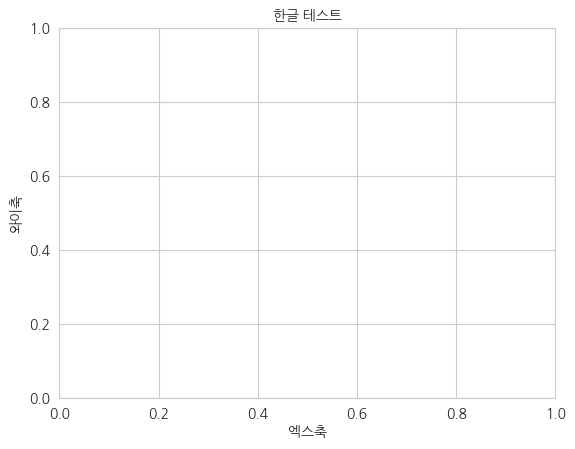

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

plt.title('한글 테스트', fontproperties=fontprop)
plt.xlabel('엑스축', fontproperties=fontprop)
plt.ylabel('와이축', fontproperties=fontprop)

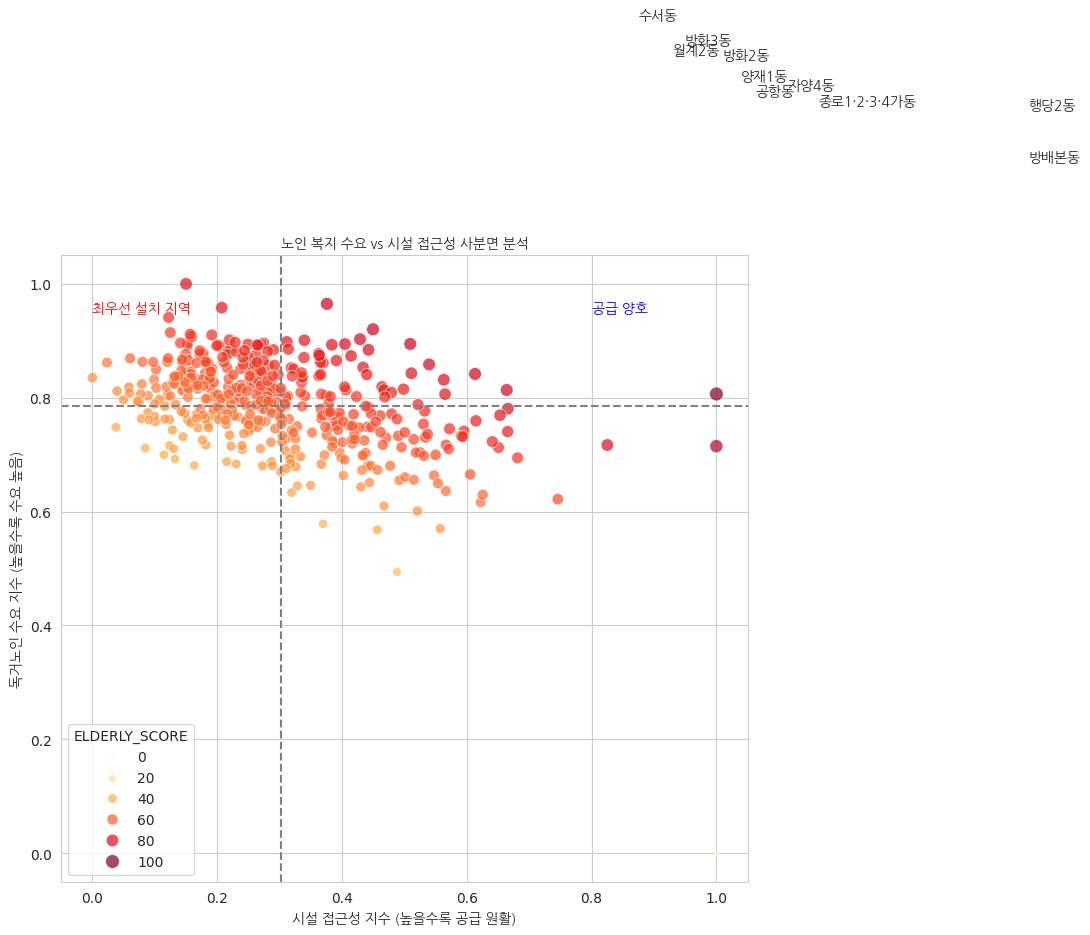

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

# =========================
# 시각화
# =========================
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    data=final_df,
    x='access_score',
    y='demand_score',
    size='ELDERLY_SCORE',
    hue='ELDERLY_SCORE',
    palette='YlOrRd',
    sizes=(10, 100),
    alpha=0.7
)

# 평균선
plt.axvline(final_df['access_score'].mean(), color='gray', linestyle='--')
plt.axhline(final_df['demand_score'].mean(), color='gray', linestyle='--')

# 상위 10개 라벨
top_risks = final_df.sort_values('ELDERLY_SCORE', ascending=False).head(10)

for i in range(len(top_risks)):
    plt.text(
        top_risks.iloc[i]['access_score'] + 0.5,
        top_risks.iloc[i]['demand_score'] + 0.5,
        top_risks.iloc[i]['행정동'],
        fontproperties=fontprop,
        fontsize=10
    )


# 제목 및 축
plt.title('노인 복지 수요 vs 시설 접근성 사분면 분석', fontproperties=fontprop)
plt.xlabel('시설 접근성 지수 (높을수록 공급 원활)', fontproperties=fontprop)
plt.ylabel('독거노인 수요 지수 (높을수록 수요 높음)', fontproperties=fontprop)



# 사분면 텍스트
plt.text(
    final_df['access_score'].max()*0.8,
    final_df['demand_score'].max()*0.95,
    '공급 양호',
    fontproperties=fontprop,
    color='blue'
)

plt.text(
    final_df['access_score'].min(),
    final_df['demand_score'].max()*0.95,
    '최우선 설치 지역',
    fontproperties=fontprop,
    color='red'
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1799/4070551971.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48513 (\N{HANGUL SYLLABLE BUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52380 (\N{HANGUL SY

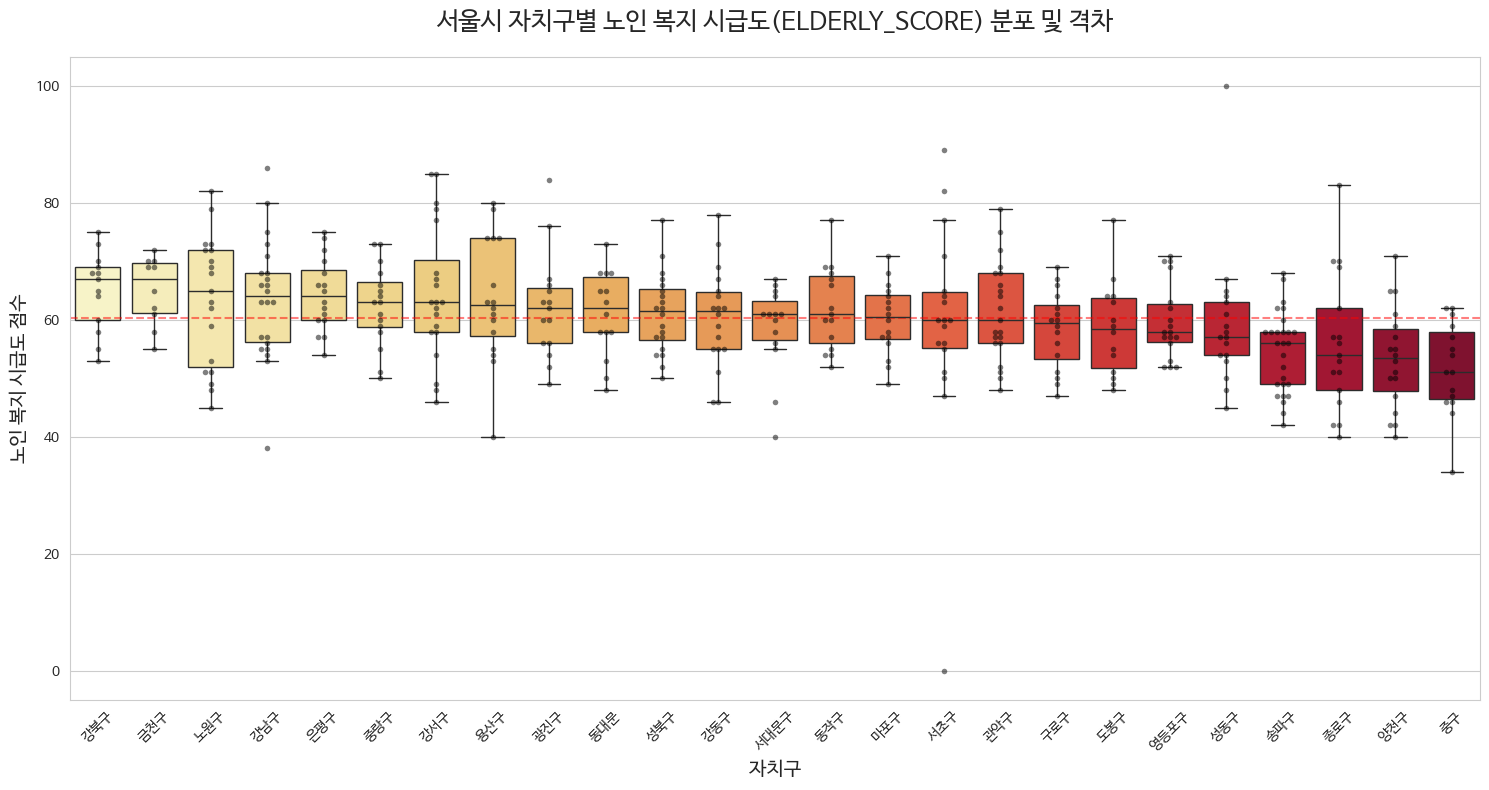

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 1. 폰트 직접 지정 (코랩 경로)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)

# 2. 데이터 정렬 (중앙값 기준으로 내림차순 정렬하여 가독성 향상)
order = final_df.groupby('자치구')['ELDERLY_SCORE'].median().sort_values(ascending=False).index

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# 3. 박스 플롯 및 개별 동네 포인트(Swarmplot) 겹쳐 그리기
# 박스 플롯: 전반적인 분포와 사분위수 표시
sns.boxplot(
    data=final_df,
    x='자치구',
    y='ELDERLY_SCORE',
    order=order,
    palette='YlOrRd',
    fliersize=0 # 이상치는 개별 포인트와 겹치므로 제거
)

# 스웜 플롯: 실제 행정동 하나하나를 점으로 표시 (격차를 시각적으로 더 잘 보여줌)
sns.swarmplot(
    data=final_df,
    x='자치구',
    y='ELDERLY_SCORE',
    order=order,
    color='black',
    size=4,
    alpha=0.5
)

# 4. 폰트 수동 적용 (제목, 축 레이블, 축 눈금)
plt.title('서울시 자치구별 노인 복지 시급도(ELDERLY_SCORE) 분포 및 격차', fontproperties=fm.FontProperties(fname=font_path, size=18), pad=20)
plt.xlabel('자치구', fontproperties=fm.FontProperties(fname=font_path, size=14))
plt.ylabel('노인 복지 시급도 점수', fontproperties=fm.FontProperties(fname=font_path, size=14))

# X축 자치구 이름 폰트 적용 및 회전
plt.xticks(fontproperties=font_prop, rotation=45)
plt.yticks(fontproperties=font_prop)

# 5. 인사이트 강화를 위한 평균선
plt.axhline(final_df['ELDERLY_SCORE'].mean(), color='red', linestyle='--', alpha=0.5, label='서울시 평균')

plt.tight_layout()
plt.show()

In [ ]:
# 1. 행정동 경계와 독거노인 데이터 합치기 (시각화용)
map_data = admin_dong_map.merge(df_solo, left_on='ADM_NM', right_on='동')

# 2. 배경 지도 띄우기 (위험 점수 기준 Choropleth)
# m 객체에 지도를 담습니다.
m = map_data.explore(
    column='SHORTAGE_INDEX', # 색상을 결정할 컬럼
    cmap='YlOrRd',           # 노랑-빨강 색상 테마
    tooltip=['동', 'SHORTAGE_INDEX'], # 마우스 올렸을 때 정보
    tiles='CartoDB positron',
    name="독거노인 위험도"      # 레이어 이름
)

# 3. 그 위에 노인복지시설(df) 점 찍기
# 위에서 만든 m 지도를 여기에 다시 넣어주는 방식입니다.
df.explore(
    m=m,                     # 위에서 만든 지도를 기반으로 추가
    color='blue',            # 시설 점 색상
    marker_kwds=dict(radius=2, fill=True),
    tooltip=['FAC_NM', 'FAC_ADDR'], # 시설 이름과 주소 표시
    name="노인복지시설"
)

m # 지도 표시

KeyError: '동'

In [ ]:
m.save("SHORTAGE_INDEX_지도.html")

print("✅ 지도가 HTML 파일로 저장되었습니다. 코랩 왼쪽 파일 탐색기에서 다운로드하세요!")

In [ ]:
# 분모가 0이 되는 것을 방지하기 위해 아주 작은 값(0.01)을 더합니다.

df_solo['DANGER_SHORTAGE_INDEX'] = df_solo['DANGER_DENSITY'] / (df_solo['FAC_DENSITY'] + 0.01)

# 우선순위 TOP 10 추출
priority_areas = df_solo.sort_values(by='DANGER_SHORTAGE_INDEX', ascending=False).head(10)
display(priority_areas[['구', '동', 'DANGER_DENSITY', 'FAC_DENSITY', 'DANGER_SHORTAGE_INDEX']])

In [ ]:
# 1. 행정동 경계와 독거노인 데이터 합치기 (시각화용)
map_data = admin_dong_map.merge(df_solo, left_on='ADM_NM', right_on='동')

# 2. 배경 지도 띄우기 (위험 점수 기준 Choropleth)
# m 객체에 지도를 담습니다.
m1 = map_data.explore(
    column='DANGER_SHORTAGE_INDEX', # 색상을 결정할 컬럼
    cmap='YlOrRd',           # 노랑-빨강 색상 테마
    tooltip=['동', 'DANGER_SHORTAGE_INDEX'], # 마우스 올렸을 때 정보
    tiles='CartoDB positron',
    name="독거노인 위험도"      # 레이어 이름
)

# 3. 그 위에 노인복지시설(df) 점 찍기
# 위에서 만든 m 지도를 여기에 다시 넣어주는 방식입니다.
df.explore(
    m=m1,                     # 위에서 만든 지도를 기반으로 추가
    color='blue',            # 시설 점 색상
    marker_kwds=dict(radius=2, fill=True),
    tooltip=['FAC_NM', 'FAC_ADDR'], # 시설 이름과 주소 표시
    name="노인복지시설"
)

m1 # 지도 표시

In [ ]:
m1.save("DANGER_SHORTAGE_INDEX_지도.html")

print("✅ 지도가 HTML 파일로 저장되었습니다. 코랩 왼쪽 파일 탐색기에서 다운로드하세요!")

### 동별 RISK_SCORE_NORM

In [ ]:
# 1. 행정동 경계와 독거노인 데이터 합치기 (시각화용)
map_data = admin_dong_map.merge(df_solo, left_on='ADM_NM', right_on='동')

# 2. 배경 지도 띄우기 (위험 점수 기준 Choropleth)
# m 객체에 지도를 담습니다.
m2 = map_data.explore(
    column='RISK_SCORE_NORM', # 색상을 결정할 컬럼
    cmap='YlOrRd',           # 노랑-빨강 색상 테마
    tooltip=['동', 'RISK_SCORE_NORM'], # 마우스 올렸을 때 정보
    tiles='CartoDB positron',
    name="독거노인 위험도"      # 레이어 이름
)

# 3. 그 위에 노인복지시설(df) 점 찍기
# 위에서 만든 m 지도를 여기에 다시 넣어주는 방식입니다.
df.explore(
    m=m2,                     # 위에서 만든 지도를 기반으로 추가
    color='blue',            # 시설 점 색상
    marker_kwds=dict(radius=2, fill=True),
    tooltip=['FAC_NM', 'FAC_ADDR'], # 시설 이름과 주소 표시
    name="노인복지시설"
)

m2 # 지도 표시

In [ ]:
m2.save("위험독거노인_분석_지도.html")

print("✅ 지도가 HTML 파일로 저장되었습니다. 코랩 왼쪽 파일 탐색기에서 다운로드하세요!")

### 동별 총 독거노인

In [ ]:
# 2. 배경 지도 띄우기 (위험 점수 기준 Choropleth)
# m 객체에 지도를 담습니다.
m3 = map_data.explore(
    column='계', # 색상을 결정할 컬럼
    cmap='YlOrRd',           # 노랑-빨강 색상 테마
    tooltip=['동', '계'], # 마우스 올렸을 때 정보
    tiles='CartoDB positron',
    name="독거노인 위험도"      # 레이어 이름
)

# 3. 그 위에 노인복지시설(df) 점 찍기
# 위에서 만든 m 지도를 여기에 다시 넣어주는 방식입니다.
df.explore(
    m=m3,                     # 위에서 만든 지도를 기반으로 추가
    color='blue',            # 시설 점 색상
    marker_kwds=dict(radius=2, fill=True),
    tooltip=['FAC_NM', 'FAC_ADDR'], # 시설 이름과 주소 표시
    name="노인복지시설"
)

m3 # 지도 표시

In [ ]:
m3.save("독거노인_밀집도_분석_지도.html")

print("✅ 지도가 HTML 파일로 저장되었습니다. 코랩 왼쪽 파일 탐색기에서 다운로드하세요!")

### 노인 밀도 지도

In [ ]:
# 1. 행정동 경계와 독거노인 데이터 합치기 (시각화용)
map_data = admin_dong_map.merge(df_solo, left_on='ADM_NM', right_on='동')

# 2. 배경 지도 띄우기 (위험 점수 기준 Choropleth)
# m 객체에 지도를 담습니다.
m4 = map_data.explore(
    column='ELDERLY_DENSITY', # 색상을 결정할 컬럼
    cmap='YlOrRd',           # 노랑-빨강 색상 테마
    tooltip=['동', 'ELDERLY_DENSITY'], # 마우스 올렸을 때 정보
    tiles='CartoDB positron',
    name="독거노인 위험도"      # 레이어 이름
)

# 3. 그 위에 노인복지시설(df) 점 찍기
# 위에서 만든 m 지도를 여기에 다시 넣어주는 방식입니다.
df.explore(
    m=m4,                     # 위에서 만든 지도를 기반으로 추가
    color='blue',            # 시설 점 색상
    marker_kwds=dict(radius=2, fill=True),
    tooltip=['FAC_NM', 'FAC_ADDR'], # 시설 이름과 주소 표시
    name="노인복지시설"
)

m4 # 지도 표시

In [ ]:
m4.save("노인_밀도_지도.html")

print("✅ 지도가 HTML 파일로 저장되었습니다. 코랩 왼쪽 파일 탐색기에서 다운로드하세요!")

In [ ]:
# 1. 행정동 경계와 독거노인 데이터 합치기 (시각화용)
map_data = admin_dong_map.merge(df_solo, left_on='ADM_NM', right_on='동')

# 2. 배경 지도 띄우기 (위험 점수 기준 Choropleth)
# m 객체에 지도를 담습니다.
m5 = map_data.explore(
    column='DANGER_DENSITY', # 색상을 결정할 컬럼
    cmap='YlOrRd',           # 노랑-빨강 색상 테마
    tooltip=['동', 'DANGER_DENSITY'], # 마우스 올렸을 때 정보
    tiles='CartoDB positron',
    name="독거노인 위험도"      # 레이어 이름
)

# 3. 그 위에 노인복지시설(df) 점 찍기
# 위에서 만든 m 지도를 여기에 다시 넣어주는 방식입니다.
df.explore(
    m=m5,                     # 위에서 만든 지도를 기반으로 추가
    color='blue',            # 시설 점 색상
    marker_kwds=dict(radius=2, fill=True),
    tooltip=['FAC_NM', 'FAC_ADDR'], # 시설 이름과 주소 표시
    name="노인복지시설"
)

m5 # 지도 표시

In [ ]:
m5.save("위험노인_밀도__지도.html")

print("✅ 지도가 HTML 파일로 저장되었습니다. 코랩 왼쪽 파일 탐색기에서 다운로드하세요!")